This notebook contains exploratory data analysis (EDA) on the Beijing PM2.5 weather dataset.

https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data

In [6]:
# imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

sns.set_style("whitegrid")

In [7]:
# load and display data
df = pd.read_csv("beijing_pm25.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  str    
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.3 MB


In [8]:
# missing data analysis
missing = df.isna().sum()
print("Missing values: ", missing)
print(f"Percentage of missing values in 'pm2.5': {df['pm2.5'].isna().mean() * 100:.2f}%")

# drop rows with missing target variable
df = df.dropna(subset=["pm2.5"]).reset_index(drop=True)



Missing values:  No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64
Percentage of missing values in 'pm2.5': 4.72%


In [9]:
# convert time to datetime
df["timestamp"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]]
)

Data distribution overview

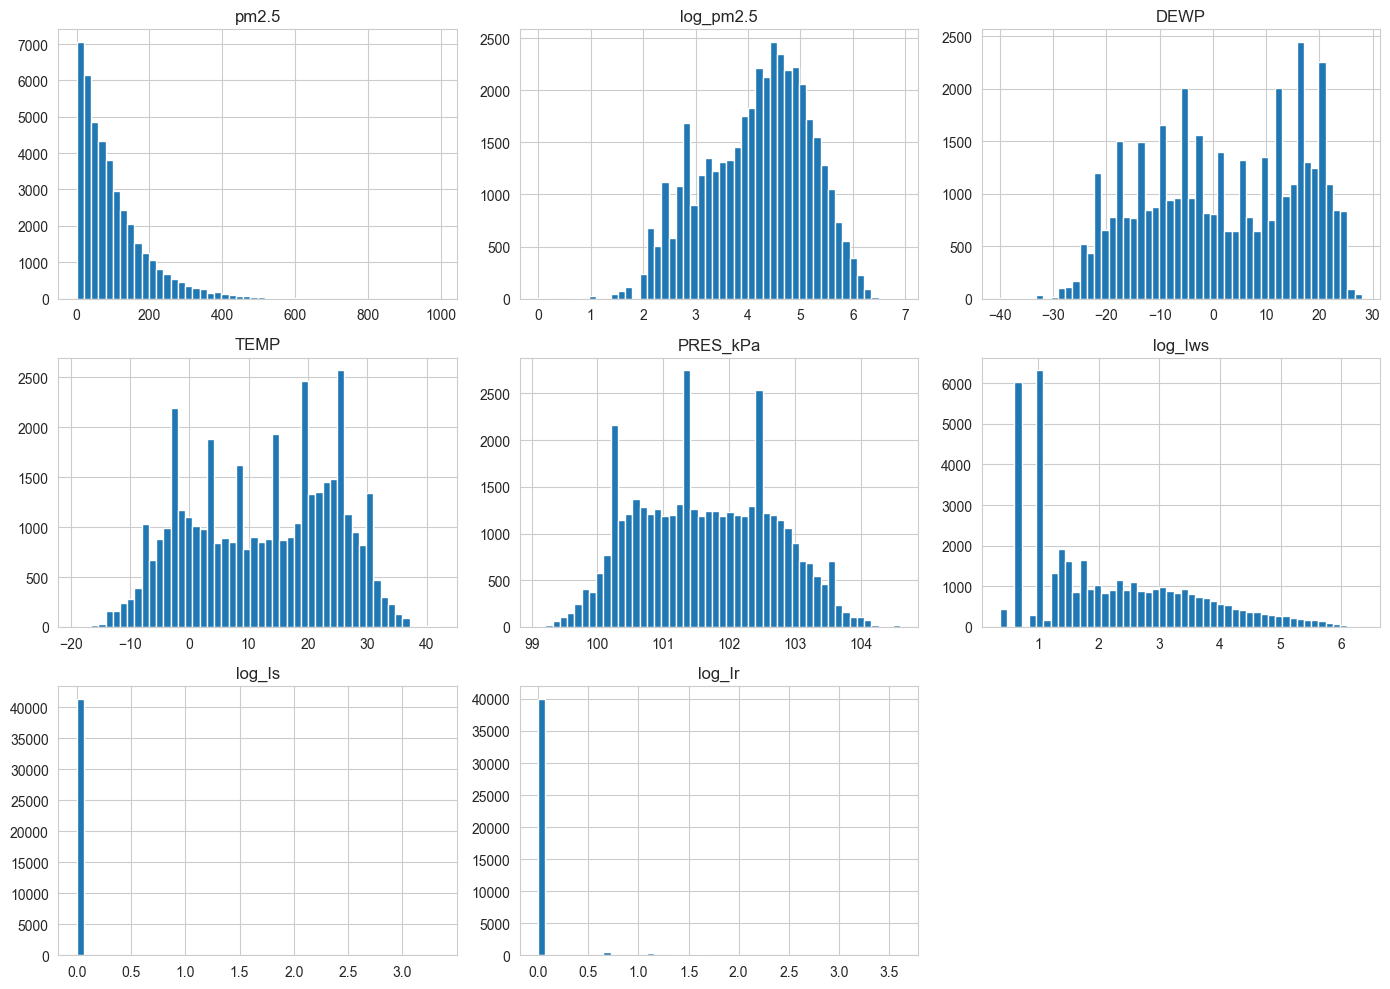

In [10]:
# define features to log-transform
log_cols = ["pm2.5", "Iws", "Is", "Ir"]

for col in log_cols:
    df[f"log_{col}"] = np.log1p(df[col])

# convert pressure to bar for better interpretability
df["PRES_kPa"] = df["PRES"] / 10.0

# define numeric features
num_features = [
    "pm2.5", "log_pm2.5", "DEWP", "TEMP", "PRES_kPa",
    "log_Iws", "log_Is", "log_Ir"
]

# summary statistics
df[num_features].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T

# histograms
df[num_features].hist(
    bins=50, figsize=(14, 10)
)
plt.tight_layout()
plt.show()

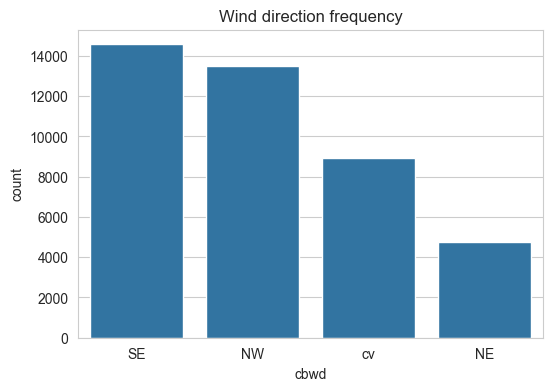

In [11]:
# wind direction is categorical
df["cbwd"].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="cbwd", order=df["cbwd"].value_counts().index)
plt.title("Wind direction frequency")
plt.show()

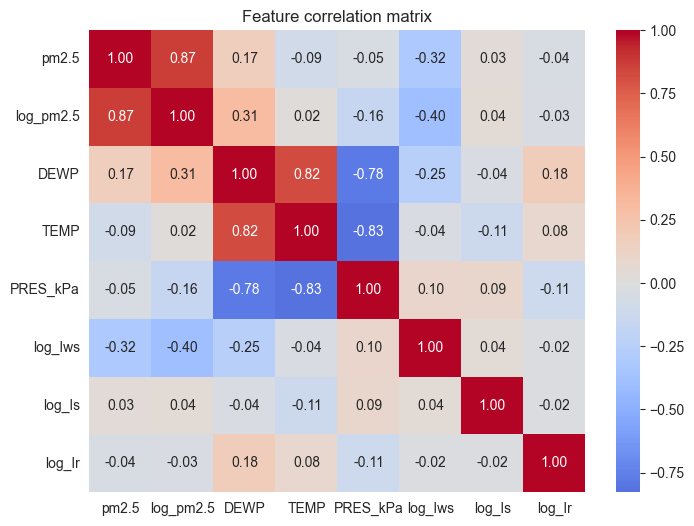

In [12]:
# correlation analysis
corr = df[num_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.show()

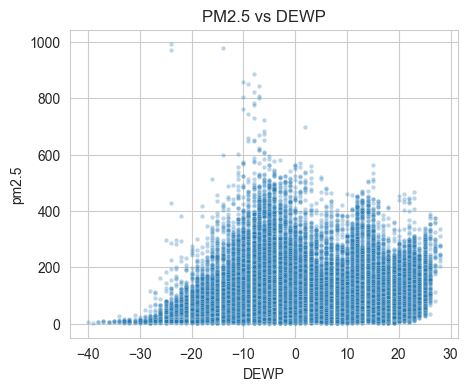

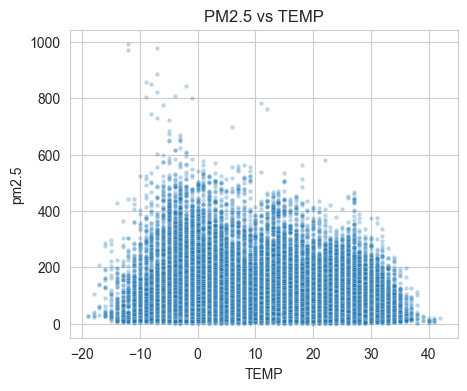

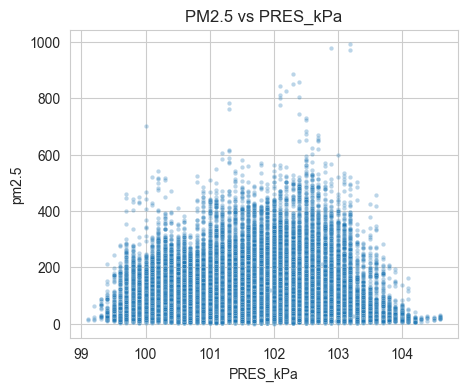

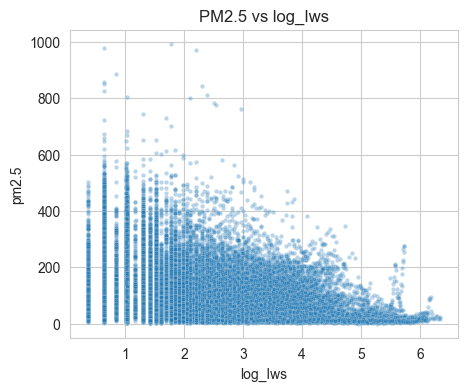

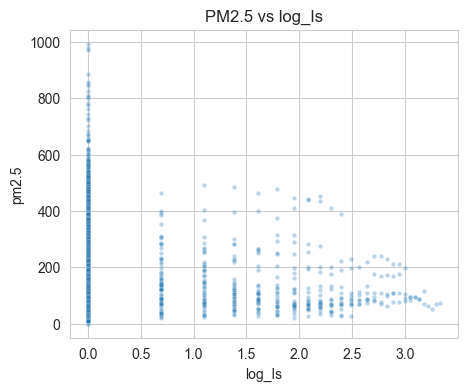

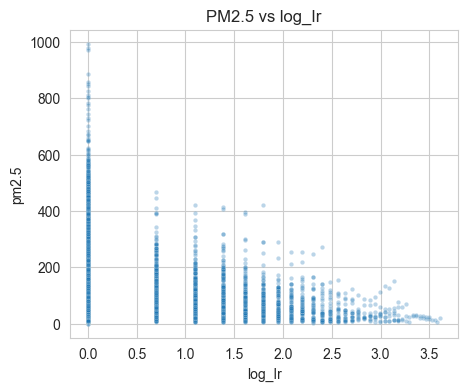

In [13]:
# pairwise relationships with PM2.5

for col in num_features:
    if col == "pm2.5" or col == "log_pm2.5":
        continue
    plt.figure(figsize=(5, 4))
    sns.scatterplot(
        x=df[col],
        y=df["pm2.5"],
        alpha=0.3,
        s=10
    )
    plt.title(f"PM2.5 vs {col}")
    plt.show()

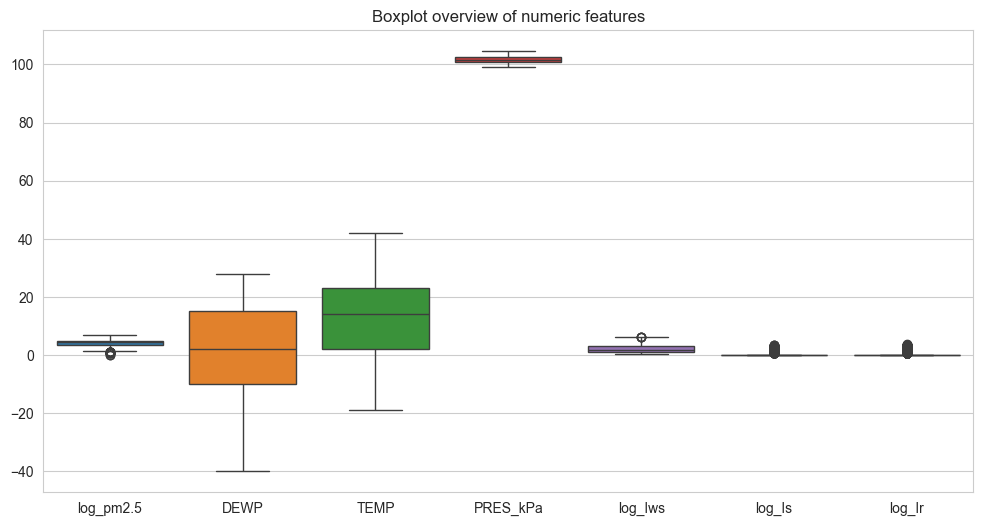

In [ ]:
# initial outlier visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_features].drop(columns=["pm2.5"]), orient="v")
plt.title("Boxplot overview of numeric features")
plt.show()